In [1]:
from IPython.display import HTML

# standard imports
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *

### Dynamics of Moving Bodies

In [2]:
J = np.array([[2, -1, 0],
              [-1, 4, 0],
              [0, 0, 3]])

In [3]:
orientation = UnitQuaternion() # identity quaternion
orientation

 1.0000 <<  0.0000,  0.0000,  0.0000 >>


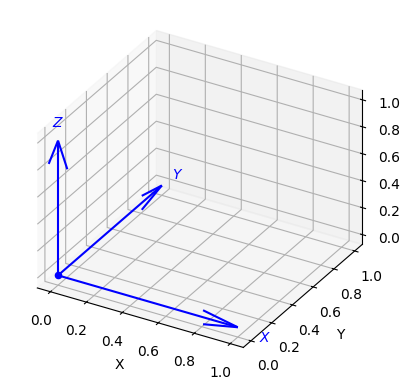

In [4]:
orientation.plot()

In [5]:
w = 0.2 * np.array([1, 2, 2])

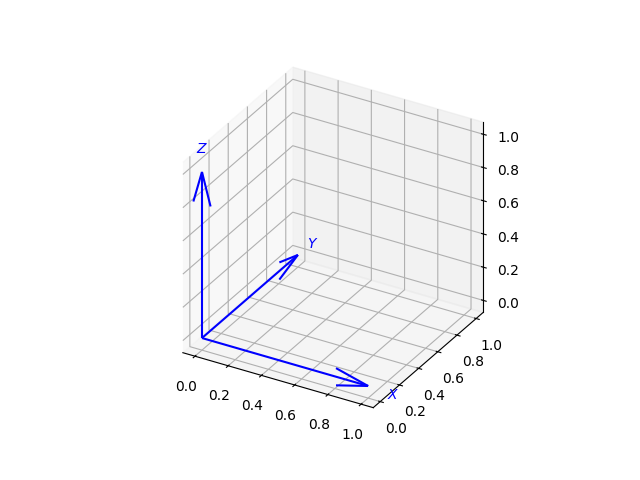

In [6]:
%matplotlib widget
dt = 0.05 # time step
def update():
    global orientation, w
    for t in np.arange(0, 10, dt):
        wd = -np.linalg.inv(J) @ (np.cross(w, J @ w)) # (3.14)
        w += wd * dt
        orientation *= UnitQuaternion.EulerVec(w * dt)
        yield orientation.R
tranimate(update())

### Transforming Forces and Torques